# Mixed-Order Tensor Factorization with MANTRA

MANTRA's name — **M**ulti-view **AN**alysis with **T**ensor and mat**R**ix
**A**lignment — reflects its core capability: jointly decomposing tensors
of *different orders* that share a common sample dimension.

A typical use case from the paper: patients profiled with both
- a **3rd-order drug-response tensor** (patients × drugs × cytokines)
- a **2nd-order RNA-seq matrix** (patients × genes)

MANTRA decomposes these jointly:

$$Y^{(T)}_{ijk} = \sum_r A_{ir} \cdot B_{jr} \cdot C^{(T)}_{kr}$$
$$Y^{(M)}_{il}  = \sum_r A_{ir} \cdot C^{(M)}_{lr}$$

The sample embeddings **A** are shared across both views, linking the
tensor and matrix through a common latent space.

In this tutorial we:

1. Generate synthetic tensor + matrix data with shared latent factors
2. Fit a joint MANTRA model
3. Compare joint vs single-view factorizations
4. Show that the shared factors capture cross-view structure

## 1. Generate Synthetic Data

We create a ground-truth factor structure and generate both a 3D tensor
and a 2D matrix from the same sample embeddings.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

import mantra

np.random.seed(42)
torch.manual_seed(42)

# Dimensions
n_samples = 60
n_slices = 8       # e.g., drugs or cell types
n_features_T = 40  # tensor features (e.g., cytokines)
n_features_M = 100 # matrix features (e.g., genes)
R_true = 4         # true number of latent factors

# Ground-truth factor matrices
A_true = np.random.randn(n_samples, R_true)       # shared sample embeddings
B_true = np.random.randn(n_slices, R_true)         # slice embeddings (tensor only)
C_T_true = np.random.randn(n_features_T, R_true)   # tensor feature embeddings
C_M_true = np.random.randn(n_features_M, R_true)   # matrix feature embeddings

# Generate tensor: Y_T[i,j,k] = sum_r A[i,r] * B[j,r] * C_T[k,r] + noise
Y_tensor = np.einsum("ir,jr,kr->ijk", A_true, B_true, C_T_true)
Y_tensor += np.random.randn(*Y_tensor.shape) * 0.3

# Generate matrix: Y_M[i,l] = sum_r A[i,r] * C_M[l,r] + noise
Y_matrix = A_true @ C_M_true.T
Y_matrix += np.random.randn(*Y_matrix.shape) * 0.3

print(f"Tensor shape: {Y_tensor.shape}  (samples x slices x features)")
print(f"Matrix shape: {Y_matrix.shape}  (samples x features)")

Tensor shape: (60, 8, 40)  (samples x slices x features)
Matrix shape: (60, 100)  (samples x features)


/Users/Buettner/projects/MANTRA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Fit Joint Model (Tensor + Matrix)

We simply pass both observations as a list. MANTRA automatically handles
the mixed orders — the matrix is internally aligned with the tensor's
slice dimension so that the shared sample embeddings **A** link both views.

In [2]:
tensor_3d = torch.tensor(Y_tensor, dtype=torch.float32)
matrix_2d = torch.tensor(Y_matrix, dtype=torch.float32)

model_joint = mantra.MANTRA(
    observations=[tensor_3d, matrix_2d],
    R=R_true,
    view_names=["tensor", "matrix"],
    use_gpu=False,
)

print(model_joint)

MANTRA Model
  n_views:    2
  n_samples:  100
  n_factors:  4
  n_features: tensor: 40, matrix: 100
  trained:    False
  device:     cpu


In [3]:
from mantra.inference.callbacks import EarlyStoppingCallback

history_joint, stopped = model_joint.fit(
    n_epochs=3000,
    learning_rate=0.005,
    seed=42,
    callbacks=[EarlyStoppingCallback(patience=100)],
)

print(f"Epochs run: {len(history_joint)}")
print(f"Final ELBO: {history_joint[-1]:.2f}")

Training:   0%|          | 0/3000 [00:00<?, ?it/s]

Training:   0%|          | 0/3000 [00:01<?, ?it/s, ELBO=81595.51]

Training:   0%|          | 1/3000 [00:01<1:29:17,  1.79s/it, ELBO=81595.51]

Training:   0%|          | 1/3000 [00:01<1:29:17,  1.79s/it, ELBO=80823.90]

Training:   0%|          | 1/3000 [00:01<1:29:17,  1.79s/it, ELBO=79787.31]

...

Training:  85%|████████▌ | 2560/3000 [00:17<00:04, 103.82it/s, ELBO=8969.54]

Training:  85%|████████▌ | 2560/3000 [00:17<00:04, 103.82it/s, ELBO=8979.61]

Training:  85%|████████▌ | 2560/3000 [00:17<00:04, 103.82it/s, ELBO=8969.02]

Training:  86%|████████▌ | 2571/3000 [00:17<00:02, 148.14it/s, ELBO=8969.02]

Epochs run: 2572
Final ELBO: 8978.36


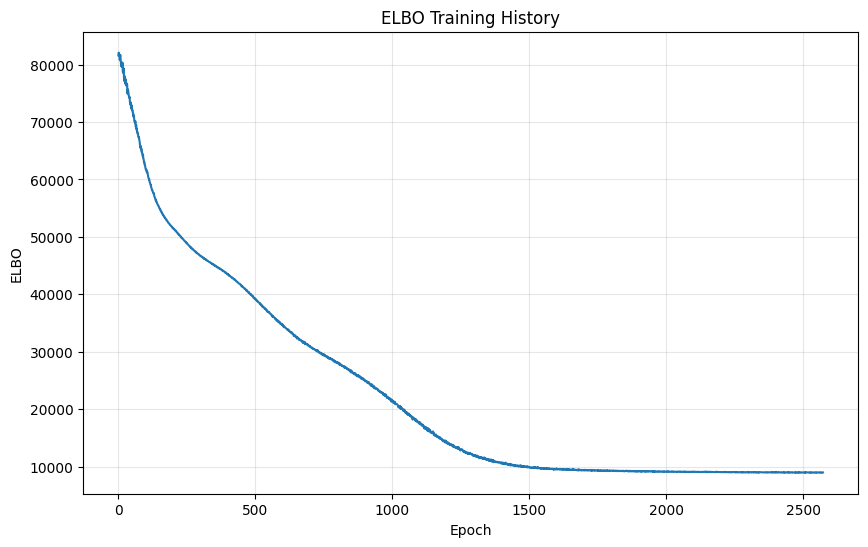

In [4]:
mantra.pl.plot_elbo(history_joint)
plt.show()

## 3. Fit Single-View Models for Comparison

To demonstrate the value of joint factorization, we also fit separate
models on the tensor and matrix individually.

In [5]:
# Tensor-only model
model_tensor = mantra.MANTRA(
    observations=tensor_3d,
    R=R_true,
    use_gpu=False,
)
history_T, _ = model_tensor.fit(
    n_epochs=3000,
    learning_rate=0.005,
    seed=42,
    callbacks=[EarlyStoppingCallback(patience=100)],
    verbose=False,
)
print(f"Tensor-only — epochs: {len(history_T)}, final ELBO: {history_T[-1]:.2f}")

Tensor-only — epochs: 2157, final ELBO: 6150.50


In [6]:
# Matrix-only model (reshape to 3D with a single slice)
matrix_3d = matrix_2d.unsqueeze(1)  # (samples, 1, features)
model_matrix = mantra.MANTRA(
    observations=matrix_3d,
    R=R_true,
    use_gpu=False,
)
history_M, _ = model_matrix.fit(
    n_epochs=3000,
    learning_rate=0.005,
    seed=42,
    callbacks=[EarlyStoppingCallback(patience=100)],
    verbose=False,
)
print(f"Matrix-only — epochs: {len(history_M)}, final ELBO: {history_M[-1]:.2f}")

Matrix-only — epochs: 1991, final ELBO: 12948.71


## 4. Compare Sample Embeddings to Ground Truth

We compare the recovered sample embeddings (A1) from each model against
the ground truth. Since factor models have sign and permutation ambiguity,
we compute **absolute Pearson correlation** between each recovered factor
and each ground-truth factor, then find the best matching.

In [7]:
from scipy.stats import pearsonr


def best_factor_correlations(A_estimated, A_ground_truth):
    """Find best absolute correlation between estimated and true factors."""
    n_factors_est = A_estimated.shape[1]
    n_factors_true = A_ground_truth.shape[1]
    corr_matrix = np.zeros((n_factors_est, n_factors_true))
    for i in range(n_factors_est):
        for j in range(n_factors_true):
            r, _ = pearsonr(A_estimated[:, i], A_ground_truth[:, j])
            corr_matrix[i, j] = abs(r)
    # Best match for each true factor
    best_corrs = corr_matrix.max(axis=0)
    return best_corrs, corr_matrix


# Get sample embeddings from each model
A1_joint = model_joint.get_sample_embeddings().numpy()
A1_tensor = model_tensor.get_sample_embeddings().numpy()
A1_matrix = model_matrix.get_sample_embeddings().numpy()

corrs_joint, _ = best_factor_correlations(A1_joint, A_true)
corrs_tensor, _ = best_factor_correlations(A1_tensor, A_true)
corrs_matrix, _ = best_factor_correlations(A1_matrix, A_true)

print("Best |correlation| with ground truth per factor:")
print(f"  Joint (tensor+matrix): {corrs_joint}")
print(f"  Tensor only:           {corrs_tensor}")
print(f"  Matrix only:           {corrs_matrix}")
print()
print(f"  Joint mean:   {corrs_joint.mean():.4f}")
print(f"  Tensor mean:  {corrs_tensor.mean():.4f}")
print(f"  Matrix mean:  {corrs_matrix.mean():.4f}")

Best |correlation| with ground truth per factor:
  Joint (tensor+matrix): [0.99987387 0.99979624 0.9999549  0.99989385]
  Tensor only:           [0.99987317 0.99959296 0.99995088 0.99985234]
  Matrix only:           [0.19304164 0.11311998 0.11240647 0.18235192]

  Joint mean:   0.9999
  Tensor mean:  0.9998
  Matrix mean:  0.1502


The joint model should recover the shared latent structure at least as
well as either single-view model, because it benefits from both data
sources simultaneously.

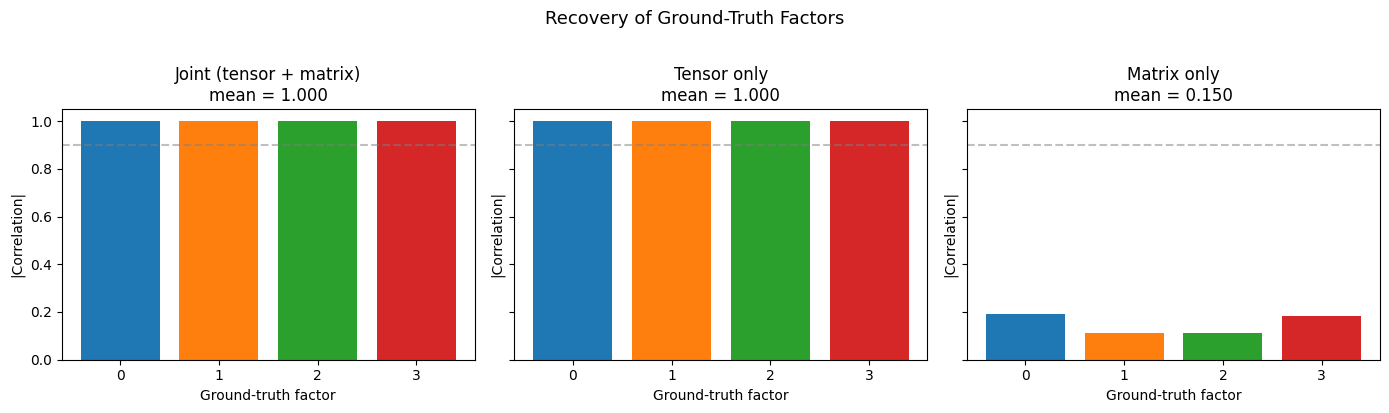

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, corrs, title in zip(
    axes,
    [corrs_joint, corrs_tensor, corrs_matrix],
    ["Joint (tensor + matrix)", "Tensor only", "Matrix only"],
):
    bars = ax.bar(range(len(corrs)), corrs, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Ground-truth factor")
    ax.set_ylabel("|Correlation|")
    ax.set_title(f"{title}\nmean = {corrs.mean():.3f}")
    ax.set_xticks(range(len(corrs)))
    ax.axhline(0.9, ls="--", color="gray", alpha=0.5)

plt.suptitle("Recovery of Ground-Truth Factors", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Variance Explained

The joint model decomposes variance across both views. Per-view R²
shows how well each factor explains each data modality.

In [9]:
r2 = mantra.tl.variance_explained(model_joint)
print(f"Total R²: {r2['total']:.4f}")
print(f"\nPer-factor R²:")
print(r2["per_factor"])

if "per_view" in r2:
    print(f"\nPer-view R²:")
    for view, score in r2["per_view"].items():
        print(f"  {view}: {score:.4f}")

Total R²: 0.9792

Per-factor R²:
                r2
Factor_3  0.473528
Factor_1  0.236433
Factor_0  0.218627
Factor_2  0.148636

Per-view R²:
  view_0: 0.9793
  view_1: 0.9789


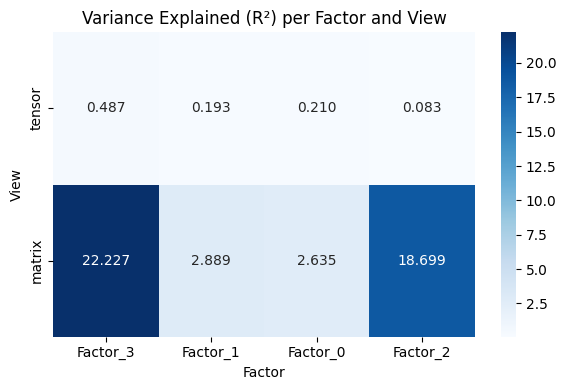

In [10]:
fig = mantra.pl.variance_explained(model_joint)
plt.show()

## 6. Reconstruction Quality

In [11]:
Y_hat = model_joint.get_reconstructed()

# Tensor view: first n_features_T features
Y_hat_tensor = Y_hat[:, :, :n_features_T]
rmse_T = mantra.tl.rmse_loss(Y_hat_tensor, tensor_3d)

# Matrix view: remaining features, only slice 0 has real data
Y_hat_matrix = Y_hat[:, 0, n_features_T:]
rmse_M = torch.sqrt(torch.mean((Y_hat_matrix - matrix_2d) ** 2))

print(f"Reconstruction RMSE (tensor view): {rmse_T:.4f}")
print(f"Reconstruction RMSE (matrix view): {rmse_M:.4f}")

Reconstruction RMSE (tensor view): 0.3005
Reconstruction RMSE (matrix view): 0.2840


## 7. Inspect Factor Structure

### Slice Embeddings (A2)

The slice embeddings capture structure in the tensor view. For the matrix
view, only the first slice carries signal (the rest are masked).

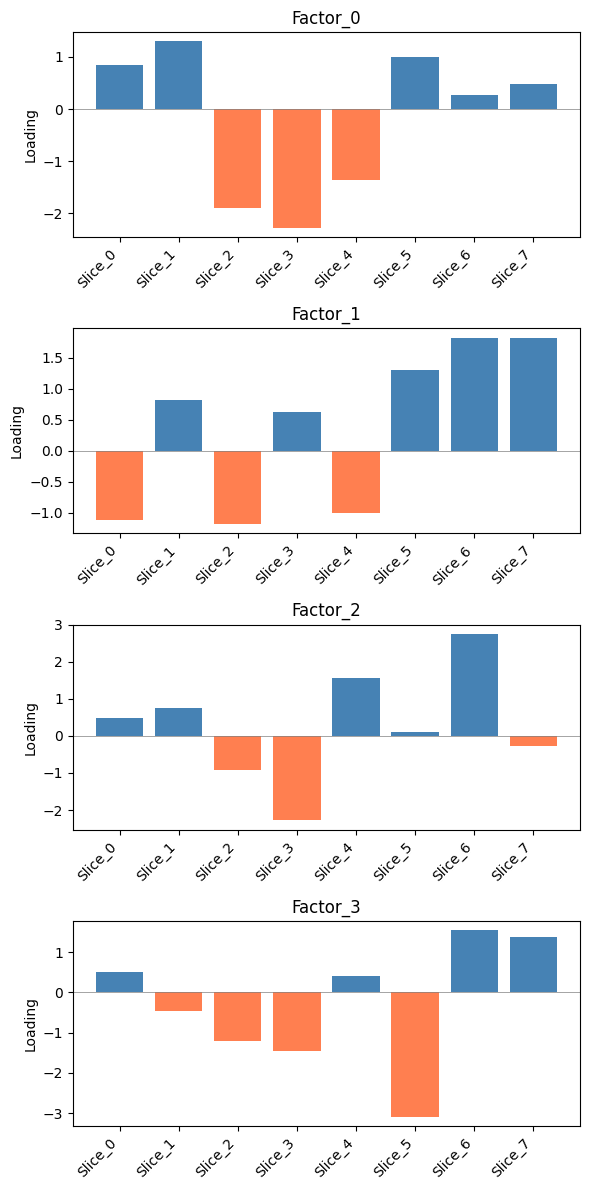

In [12]:
fig = mantra.pl.slice_weights(model_joint, factor_idx=[0, 1, 2, 3])
plt.show()

### Feature Embeddings (A3)

We can inspect feature loadings per view. The tensor features and matrix
features load on the same factors but capture different aspects.

In [13]:
A3_tensor = model_joint.get_feature_embeddings(view=0, as_df=True)
A3_matrix = model_joint.get_feature_embeddings(view=1, as_df=True)

print(f"Tensor feature embeddings: {A3_tensor.shape}")
print(f"Matrix feature embeddings: {A3_matrix.shape}")

# Show top features per factor for the matrix view
for col in A3_matrix.columns[:2]:
    top5 = A3_matrix[col].abs().nlargest(5)
    print(f"\nTop 5 matrix features for {col}:")
    for feat, val in top5.items():
        print(f"  {feat}: {A3_matrix.loc[feat, col]:.3f}")

Tensor feature embeddings: (40, 4)
Matrix feature embeddings: (100, 4)

Top 5 matrix features for Factor_0:
  Feature_1_59: 2.807
  Feature_1_28: 2.633
  Feature_1_69: 2.260
  Feature_1_7: -2.150
  Feature_1_77: 2.012

Top 5 matrix features for Factor_1:
  Feature_1_80: -2.401
  Feature_1_9: 2.177
  Feature_1_37: -2.070
  Feature_1_35: 1.985
  Feature_1_59: 1.858


## 8. Adding Missing Data

A key advantage of MANTRA is handling missing values. In real data,
not all samples may have all slice measurements. Let's demonstrate
by randomly masking 20% of the tensor entries.

In [14]:
tensor_missing = tensor_3d.clone()
mask = torch.rand_like(tensor_missing) < 0.2
tensor_missing[mask] = float("nan")

n_nan = torch.isnan(tensor_missing).sum().item()
n_total = tensor_missing.numel()
print(f"Masked {n_nan}/{n_total} entries ({100*n_nan/n_total:.1f}%)")

model_missing = mantra.MANTRA(
    observations=[tensor_missing, matrix_2d],
    R=R_true,
    view_names=["tensor", "matrix"],
    use_gpu=False,
)

history_miss, _ = model_missing.fit(
    n_epochs=3000,
    learning_rate=0.005,
    seed=42,
    callbacks=[EarlyStoppingCallback(patience=100)],
    verbose=False,
)

A1_missing = model_missing.get_sample_embeddings().numpy()
corrs_missing, _ = best_factor_correlations(A1_missing, A_true)
print(f"\nFactor recovery with 20% missing data:")
print(f"  Best |corr|: {corrs_missing}")
print(f"  Mean:  {corrs_missing.mean():.4f} (vs {corrs_joint.mean():.4f} without missing)")

Masked 3846/19200 entries (20.0%)



Factor recovery with 20% missing data:
  Best |corr|: [0.99984114 0.99972264 0.99994636 0.99987737]
  Mean:  0.9998 (vs 0.9999 without missing)


## Summary

This tutorial demonstrated MANTRA's mixed-order factorization capability:

| Concept | Details |
|---------|---------|
| Mixed-order input | Pass `observations=[tensor_3d, matrix_2d]` — MANTRA handles alignment |
| Shared embeddings | Sample embeddings (A1) are shared across all views |
| View-specific features | Each view has its own feature embeddings (A3) |
| Joint advantage | Multi-view model leverages complementary information |
| Missing data | NaN entries are automatically masked during training |

This is the same approach used in the MANTRA paper for the CLL dataset,
where a drug-response tensor (patients × drugs × cytokines) was jointly
decomposed with an RNA-seq matrix (patients × genes) to discover
IGHV-associated patient subgroups.